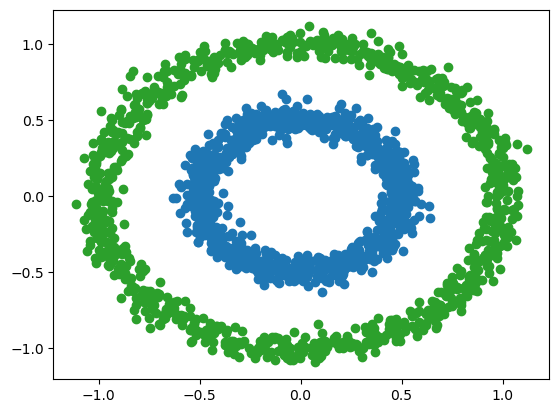

In [1]:
import numpy as np
import queue
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

class DBSCAN:
    def __init__(self,epsilon,MinPts):
        """
        DBSCAN算法
        参数：
        epsilon：邻域半径
        MinPts：核心对象最少需要的邻居数
        """
        self.epsilon = epsilon
        self.MinPts = MinPts
        self.core_objects = [] # 核心对象
        self.c = {} # 簇划分结果

    def calculate_distance(self,x1,x2):
        """计算两个点之间的距离"""
        return np.sqrt(np.sum((x1-x2)**2))

    def fit(self,X):
        """训练"""
        # 寻找核心对象
        for i in range(len(X)):
            x_neighbors = []
            for j in range(len(X)):
                if self.calculate_distance(X[i],X[j]) < self.epsilon:
                    x_neighbors.append(j)
            if len(x_neighbors) >= self.MinPts:
                self.core_objects.append(i)
        # 划分簇
        # 初始化聚类簇数
        k = 0 
        # 初始化未访问样本集合
        gamma = np.arange(len(X))
        while len(self.core_objects) > 0:
            # 记录当前未访问的样本集合
            gamma_old = gamma
            # 随机选择一个核心对象
            o = np.random.choice(self.core_objects)
            # 初始化队列
            Q = queue.Queue()
            Q.put(o)
            # 标记该核心对象已访问
            gamma = np.setdiff1d(gamma, o)
            while not Q.empty():
                # 取出队首元素
                q = Q.get()
                q_neighbors = []    
                # 判断该元素是否为核心对象
                for i in range(len(X)):
                    if self.calculate_distance(X[q],X[i]) < self.epsilon:
                        q_neighbors.append(i)
                # 该元素为核心对象，将其加入簇
                if len(q_neighbors) >= self.MinPts:
                    # q的邻居中未被访问的样本加入队列
                    for neighbor in q_neighbors:
                        if neighbor in gamma:
                            Q.put(neighbor)
                            # 标记delta为已访问
                            gamma = np.setdiff1d(gamma, neighbor)
            # 生成簇
            self.c[k] = np.setdiff1d(gamma_old, gamma)
            # 标记该簇的核心对象
            k += 1
            # 移去该簇的核心对象
            self.core_objects = np.setdiff1d(self.core_objects,self.c[k-1])
        # 噪声点
        self.c[-1] = np.setdiff1d(np.arange(len(X)), np.concatenate(list(self.c.values())))

                

if __name__ == '__main__':
    # 加载数据
    X, y = make_circles(n_samples=2000, noise=0.05, factor=0.5)
    # 实例化DBSCAN
    dbscan = DBSCAN(epsilon=0.2, MinPts=50)
    # 训练
    dbscan.fit(X)
    # 可视化
    for i in dbscan.c:
        if i != -1:
         # 绘制簇
            plt.scatter(X[dbscan.c[i],0],X[dbscan.c[i],1])
         # 绘制噪声
        plt.scatter(X[dbscan.c[-1],0],X[dbscan.c[-1],1],marker='*')
    plt.show()